# **Thông tin nhóm**
- Lớp: ML Labs 23KHDL1
- Nhóm: 4
- Sinh viên: 
    - 23127102 - Lê Quang Phúc
    - 23127212 - Nguyễn Quang Đăng Khoa
    - 23127241 - Đoàn Thành Phát
    - 23127332 - Trần Tiến Cường
    - 23127442 - Trầm Hữu Nhân


# **Model Implementation and Comparison**

## **1. Thư viện và thiết lập cấu hình chung**

In [1]:
import ast
import os
import pickle
import re
import numpy as np
import pandas as pd
import tensorflow as tf
import unicodedata
import time
import matplotlib.pyplot as plt
import seaborn as sns

from gensim.models.fasttext import load_facebook_vectors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score
from io import BytesIO
from IPython.display import display, SVG

np.random.seed(42)
tf.random.set_seed(42)

pd.set_option("display.max_colwidth", 120)
df = pd.read_csv("../data/processed_data.csv")

## **2. Model Architecture**
### 2.1 Paradigm 
Hệ thống sử dụng Deep Learning làm lõi chính cho bài toán, nhóm áp dụng gợi ý dựa trên nội dung (recommendation) và phát biểu lại bài toán dưới dạng Phân loại văn bản đa lớp (multi-class text classification).

### 2.2 Model
Nhóm cải tiến dựa trên cấu trúc TextCNN (Convolutional Neural Networks for Test) được đề xuất bởi [Yoon Kim, 2014](https://arxiv.org/abs/1408.5882) kết hợp pre-train Word Embedding với các thành phần chính gồm:
- **Input Layer**: Tiếp nhận dữ liệu văn bản thô từ người dùng hoặc từ các câu mô tả (`comment`) trong tập dữ liệu.

- **TextVectorization Layer**: Thực hiện chuẩn hóa văn bản và chuyển đổi các từ thành các số nguyên (tokens). Lớp này được cấu hình với độ dài chuỗi cố định để đảm bảo tính nhất nhất quán cho các lớp học sâu phía sau.

- **Embedding Layer**: Chuyển đổi các token số nguyên thành các vector đặc trưng trong không gian `300 chiều`. Nhóm sử dụng trọng số từ `FastText` đã được huấn luyện sẵn trên kho dữ liệu tiếng Việt khổng lồ.

- **Multi-branch Conv1D Layers**: : Dữ liệu được đưa qua 3 nhánh tích chập song song với các kích thước cửa sổ (kernel size) lần lượt là 3, 4, và 5.

- **Multi-branch GlobalMaxPooling1D Layers**: Sau mỗi lớp Conv1D, Global Max Pooling sẽ trích xuất giá trị lớn nhất từ mỗi filter, nhằm nhận diện được các đặc trưng quan trọng nhất trong câu đầu vào.

- **Concatenate Layer**: Tập hợp tất cả các đặc trưng nổi bật từ 3 nhánh thành một vector duy nhất, tạo ra một biểu diễn toàn diện về mặt ngữ nghĩa và ngữ cảnh của câu truy vấn.

- **BatchNormalization Layer**: Chuẩn hóa các đầu ra từ lớp Concatenate, giúp ổn định hóa quá trình huấn luyện, giảm thiểu sự phụ thuộc vào việc khởi tạo trọng số ban đầu và tăng tốc độ hội tụ.

- **Dropout Layer**: Áp dụng tỷ lệ loại bỏ `rate=0.5` trong quá trình huấn luyện để chống hiện tượng học vẹt (overfitting).

- **Dense Layer (hidden)**: Một lớp kết nối đầy đủ với `256 nơ ron` và hàm kích hoạt `ReLU`, giúp mô hình học các tổ hợp đặc trưng phi tuyến tính phức tạp hơn từ dữ liệu văn bản.

- **Dense Layer (output)**: Sử dụng hàm kích hoạt `Softmax` để chuyển đổi điểm số thành phân phối xác suất, từ đó xác định các địa điểm phù hợp nhất với yêu cầu của người dùng.
### 2.3 Pipeline
Pipeline giải pháp được lập trình liền mạch, đi từ dữ liệu thô đến hệ gợi ý hoàn chỉnh được thể hiện qua các bước sau: 
- Tiền xử lý dữ liệu cho mô hình
- Chiến lược chia tập dữ liệu
- Quá trình huấn luyện
- Đánh giá và huấn luyện trên toàn bộ dữ liệu
- Suy luận và hậu xử lý cho bài toán gợi ý

### 2.4 Độ phù hợp với dữ liệu/bài toán
Việc lựa chọn **TextCNN** cho dự án này là hoàn toàn hợp lý bởi vì: 
- Dữ liệu đầu vào chủ yếu là các bình luận đánh giá ngắn/trung bình (`commments`), dạng văn bản này thường chứa các cụm từ thể hiện ý nghĩa hoặc đặc trưng rất rõ ràng (ví dụ: "view đẹp", "đồ ăn ngon", "phục vụ tốt").
- **TextCNN** thực hiện tốt trong việc trích xuất các đặc trưng cục bộ / cụm từ `n-gram` thông qua các cửa sổ trượt kích thước 3, 4, 5. Điều này hoàn toàn phù hợp với văn bản ngắn có mật độ thông tin cao như bình luận.
- Bài toán tập trung vào tính hiệu quả của các lựa chọn hàng đầu thay vì chỉ đánh giá một kết quả đúng nhất. Do đó, việc sử dụng `Top-5 accuracy` làm chuẩn mực đánh giá là hoàn toàn phản ánh đúng bản chất của một hệ thống Recommendation System.
- So với các mô hình ngữ cảnh sâu như RNN, LSTM hay các mô hình lớn như Transformers (BERT), **TextCNN** có khả năng tính toán song song tính năng vô cùng mạnh mẽ do bản chất của tích chập. Điều này giúp đẩy nhanh tốc độ hội tụ khi train cũng như đạt tính thời gian thực khi dự đoán (Inference).


## **3. Tiền xử lý dữ liệu cho mô hình**

### 3.1 Trích xuất điểm và nội dung bình luận
Từ cột dữ liệu bình luận gốc được bóc tách và phân rã thành một danh sách các câu văn bản (`comment_list`), đóng vai trò quan trọng cho quá trình vector hóa và huấn luyện mô hình học sâu ở các bước tiếp theo.

In [2]:
def extract_comments(value):
    if pd.isna(value):
        return []
    text = str(value).strip()
    if text in {"", "[]"}:
        return []
    matches = re.findall(r"\{(.*?)\}", text, flags=re.DOTALL)

    return [m.strip() for m in matches if m and m.strip()]

def parse_comment_scores(value):
    if pd.isna(value) or str(value).strip() in {"", "[]"}:
        return np.nan
    try:
        scores = ast.literal_eval(str(value))
        if isinstance(scores, (list, tuple)) and scores:
            return float(np.mean(scores))
    except (ValueError, SyntaxError):
        return np.nan   
    
    return np.nan

df["comment_list"] = df["Comments"].apply(extract_comments)

### 3.2 Tạo comment cho các địa điểm thiếu dữ liệu
Trong quá trình phân tích và khảo sát tập dữ liệu, nhóm nhận thấy một số địa điểm hoàn toàn không có dữ liệu bình luận (`comments`) từ quá trình thu thập dữ liệu. Do đó, nhóm thực hiện phương pháp tổng hợp bình luận (`category` + `address` + `price`) và gán một mức điểm đánh giá mặc định ở mức tích cực là `5.0`.

In [3]:
def build_fallback_comment(row):
    category = str(row.get("Category", "")).strip()
    address = str(row.get("Address", "")).strip()
    price_min = row.get("Price_min", None)
    price_max = row.get("Price_max", None)

    parts = [] 

    if category == "attraction":
        parts.append("Đây là địa điểm du lịch")
    elif category == "hotel":
        parts.append("Đây là khách sạn")
    else:
        parts.append("Đây là quán ăn")

    parts.append(f"ở {address}.") if address else None

    if pd.notna(price_min) and pd.notna(price_max):
        parts.append(f"và có giá từ: {int(price_min)} đến {int(price_max)} VNĐ.")
    elif pd.notna(price_min):
        parts.append(f"và có giá trên: {int(price_min)} VNĐ.")
    elif pd.notna(price_max):
        parts.append(f"và có giá dưới: {int(price_max)} VNĐ.")

    return " ".join([p for p in parts if p])

mask_empty = df["comment_list"].apply(len) == 0
if mask_empty.any():
    df.loc[mask_empty, "comment_list"] = df.loc[mask_empty].apply(
        lambda row: [build_fallback_comment(row)],
        axis=1,
    )
    df.loc[mask_empty, "Comment_scores"] = "[5.0]"

### 3.3 Tái cấu trúc bộ dữ liệu và tạo các đặc trưng xếp hạng
- Dữ liệu gốc có cấu trúc là "1 địa điểm - nhiều bình luận", để mô hình có thể học từng ngữ cảnh một cách độc lập, nhóm sử dụng hàm `explode` để phân rã thành "1 địa điểm - 1 bình luận" theo từng dòng. 

- Trong hệ thống gợi ý, việc có một thang điểm chuẩn xác để xếp hạng các địa điểm ở đầu ra là rất quan trọng. Nhóm đã tạo ra một đặc trưng mới mang tên `rank_score` thông qua chiến lược điền khuyết ưu tiên như sau:
    - Ưu tiên sử dụng điểm đánh giá `score` từ bộ dữ liệu.
    - Đối với các địa điểm bị thiếu score thì tính toán điểm trung bình của toàn bộ các bình luận hiện có tại địa điểm đó (`comment_score_mean`) để thay thế.
    - Nếu địa điểm vẫn hoàn toàn không có cả điểm đánh giá lẫn điểm bình luận thì sẽ lấy trung bình cộng `rank_score` trên toàn bộ tập dữ liệu.

In [4]:
df = df.explode("comment_list", ignore_index=True)

df["comment_text"] = df["comment_list"].fillna("").astype(str).str.strip()
df = df.dropna(subset=["comment_text"])
df = df[df["comment_text"] != ""]

df["comment_score_mean"] = df["Comment_scores"].apply(parse_comment_scores)

df["rank_score"] = df["Score"].copy()
df.loc[df["rank_score"].isna(), "rank_score"] = df["comment_score_mean"]
df["rank_score"] = df["rank_score"].fillna(df["rank_score"].mean())

df["Name"] = df["Name"].astype(str)

## **4. Chiến lược chia tập dữ liệu**


### 4.1 Mã hóa nhãn
Tên các địa điểm ở dạng chuỗi được mã hóa thành các nhãn số nguyên, biến `label_id` này đóng vai trò là ground-truth (biến mục tiêu) để mô hình có thể hiểu và tính toán hàm mất mát (loss function) trong quá trình huấn luyện.

In [5]:
label_encoder = LabelEncoder()
df_main = df.copy()
df_main["label_id"] = label_encoder.fit_transform(df_main["Name"])

### 4.2 Thực hiên phân chia các tập dữ liệu
Do đặc thù của dữ liệu thực tế tồn tại hiện tượng mất cân bằng, có những địa điểm thu thập được rất ít bình luận (dưới 6 bình luận). Nếu chia ngẫu nhiên, các mẫu này có thể rơi vào tập `Validation` hoặc `Test` khiến mô hình mất đi dữ liệu để học, hoặc gây lỗi chia dữ liệu. 

Để giải quyết các vấn đề trên, nhóm đã thực hiện chiến lược phân chia dữ liệu như sau:
- Tách riêng các địa điểm có ít hơn 6 bình luận (`rare_classes`).
- Sau khi dữ liệu hiếm bị loại ra, phần dữ liệu còn lại thay vì được chia ngẫu nhiên đơn thuần thì nhóm sẽ áp dụng lấy mẫu phân từng (`stratify=y`). Có nghĩa là mỗi khi chia ra theo tỷ lệ `70% Train - 15% Validation - 15% Test` nhưng vẫn đảm bảo được số lượng mẫu đồng đều trên cả 3 tập đối với mỗi địa điểm khác nhau.

In [ ]:
class_counts = df_main["label_id"].value_counts()
rare_classes = class_counts[class_counts < 6].index
mask_rare = df_main["label_id"].isin(rare_classes)

df_train_rare = df_main[mask_rare]
df_rest = df_main[~mask_rare]

X = df_rest["comment_text"]
y = df_rest["label_id"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
 )
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
 )

# Train (70% + rare classes)
if not df_train_rare.empty:
    X_train = pd.concat([X_train, df_train_rare["comment_text"]], ignore_index=True)
    y_train = np.concatenate([y_train, df_train_rare["label_id"].values])

# In ra số lượng dòng của từng tập
print("Train:", len(X_train))
print("Validation:", len(X_valid))
print("Test:", len(X_test))

Tập train: 97189
Tập validation: 20066
Tập test: 20067


### 4.3 Xây dựng luồng dữ liệu
- `TextVectorization Layer` thực hiện chuyển đổi chuỗi văn bản thành các mảng số nguyên với không gian từ vựng giới hạn ở mức `max_tokens = 20000` từ phổ biến nhất trên tập huấn luyện (train), yếu tố độ dài câu đầu ra được cố định ở `sequence_length = 100` tokens.

- `Embedding Layer` sẽ tiếp nhận và chịu trách nhiệm biểu diễn các chỉ số của TextVectorization Layer thành các vector liên tục mang ý nghĩa ngữ cảnh, thay vì khởi tạo mô hình ngữ nghĩa ngẫu nhiên để học từ đầu thì nhóm tải mô hình đã được pre-train FastText phiên bản tiếng Việt ([cc.vi.300.bin](https://fasttext.cc/docs/en/crawl-vectors.html)):
    - Một ma trận nhúng trọng số (`embedding_matrix`) được khởi tạo cẩn thận, bằng cách duyệt qua từ điển đã được vector hóa ở trên, ma trận này trích xuất và lưu trữ vector ngữ nghĩa FastText tương ứng cho từng ký tự. Ma trận này sau đó sẽ được nạp trực tiếp vào lớp Embedding của mạng TextCNN để cung cấp khả năng hiểu biết ngôn ngữ phong phú ngay từ giai đoạn khởi đầu.

- Các nhãn phân loại dạng số nguyên (`y`) sẽ được mã hóa `one-hot` thành các vector nhị phân nhiều chiều, đây là chuẩn đầu vào để tương thích với hàm mất mát `CategoricalCrossentropy` mà tôi đã dùng ở bên dưới.

- Việc nạp toàn bộ tập dữ liệu và bộ nhớ (RAM) cùng lúc sẽ không hiệu quả, nhóm chia nhỏ dữ liệu thành các `batch_size = 64` giúp cân bằng giữa tốc độ hội tụ và phần cứng.

In [7]:
max_tokens = 20000
sequence_length = 100
batch_size = 64
embedding_dim = 300
fasttext_path = r"D:\hcmus\sem8\ML\cc.vi.300.bin"

@tf.keras.utils.register_keras_serializable()
def custom_standardize(text):
    text = tf.strings.lower(text)
    text = tf.strings.regex_replace(text, r"\s+", " ")
    return text

vectorizer = tf.keras.layers.TextVectorization(
    standardize=custom_standardize,
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length,
    )   
vectorizer.adapt(X_train.values)

vocab = vectorizer.get_vocabulary()
vocab_size = len(vocab)

ft_model = load_facebook_vectors(fasttext_path)

embedding_matrix = np.zeros((vocab_size, embedding_dim), dtype=np.float32)
for i, token in enumerate(vocab):
    if token in ("", "[UNK]"):
        continue
    try:
        embedding_matrix[i] = ft_model.get_vector(token)
    except KeyError:
        pass

num_classes = len(label_encoder.classes_)
y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes)
y_valid_oh = tf.keras.utils.to_categorical(y_valid, num_classes)
y_test_oh = tf.keras.utils.to_categorical(y_test, num_classes)

train_ds = tf.data.Dataset.from_tensor_slices((X_train.values, y_train_oh))
train_ds = train_ds.shuffle(4096).batch(batch_size).prefetch(tf.data.AUTOTUNE)

valid_ds = tf.data.Dataset.from_tensor_slices((X_valid.values, y_valid_oh))
valid_ds = valid_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test.values, y_test_oh))
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

## **5. Quá trình huấn luyện**
Để giải quyết bài toán gợi ý dưới góc độ phân loại đa lớp, nhóm tiến hành xây dựng và biên dịch mô hình TextCNN với các tinh chỉnh để tối ưu hóa khả năng trích xuất đặc trưng và giảm thiểu hiện tượng quá khớp (overfitting):

- `Embedding Layer` sử dụng ma trận trọng số FastTest đã được đống băng (`trainable=False`) giiusp mô hình bảo toàn biểu diễn ngữ cảnh mạnh mẽ từ pre-trained model và tiết kiệm đáng kể chi phí tính toán.

- `Conv1D & GlobalMaxPooling1D` sử dụng kích thước booj lọc (kernel size) lần lượt là `3, 4, 5` và `128` filters mỗi nhánh giúp mô hình có khả năng quét và trích xuất các cụm từ ngữ nghịa `N-gram` có độ dài khác nhau.

- `Dropout (rate=0.5)` được thiết lập để ngẫu nhiên vô hiệu hóa 50% nơ-ron trong quá trình huấn luyện nhằm chống học vẹt. Cuối cùng, tín hiệu đi qua lớp ẩn `Dense (256, ReLU)` trước khi ra lớp `Output (Softmax)`.

-  Nhóm sử dụng `Adam`, một thuật toán tính toán và cập nhật trọng số của mạng nơ-ron sau mỗi vòng lặp sao cho độ lỗi giảm xuống ở mức thấp nhất. Trong xử lý ngôn ngữ tự nhiên, gradient của các từ hiếm thường rất nhỏ,    cơ chế tốc độ học thích ứng giúp mô hình bắt được tín hiệu từ các từ hiếm này cực kỳ hiệu quả, mô hình hội tụ rất nhanh, giúp tiết kiện thời gian và tài nguyên huấn luyện.

- Sử dụng `CategoricalCrossentropy` kết hợp với kỹ thuật Label Smoothing (`label_smoothing=0.1`) cho hàm mất mát, trong bài toán phải phân loại hàng ngàn phân lớp khác nhau, việc giảm độ tin cậy tuyệt đối vào 1 nhãn duy nhất giúp mô hình tránh bị phạt quá nặng, từ đó gia tăng tính tổng quát hóa.

- Thay vì Accuracy tuyệt đối, nhóm đánh giá mô hình qua `Top-5 Accuracy`, đây là độ đo tiêu chuẩn cho bài toán gợi ý.

- Để kiểm soát quá trình training diễn ra trong `30 epochs`, nhóm áp dụng một chiến lược giám sát qua danh sách các Callbacks:
    - EarlyStopping bằng cách giám sát hàm mất mát trên tập kiểm định (`val_loss`). Nếu sau `3 epochs` mô hình không có dấu hiệu cải thiện, quá trình huấn luyện sẽ dừng lại ngay lập tức và mô hình sẽ khôi phục lại trọng số tại thời điểm tốt nhất.
    
    - Khi mô hình có dấu hiệu chững lại trên `val_loss` trong `2 epochs`, tốc độ học (learning rate) sẽ được giảm đi một nửa (ban đầu được khởi tạo là `0.001` do sử dụng `Adam`).

    - Do dữ liệu các nhận xét bị mất cân bằng, nhóm sẽ thêm 1 đối tượng Callback để tính toán và theo dõi chỉ số `Macro F1-Score` (xem mỗi địa điểm độc lập) trên tập Validation ngay khi mỗi epoch kết thúc.

Epoch 1/30
1518/1519 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 8.1929 - top5_accuracy: 0.0166 - val_macro_f1: 0.0027
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 89s 56ms/step - loss: 7.8965 - top5_accuracy: 0.0230 - val_loss: 7.7795 - val_top5_accuracy: 0.0354 - learning_rate: 0.0010 - val_macro_f1: 0.0027
Epoch 2/30
1518/1519 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 7.1939 - top5_accuracy: 0.0532 - val_macro_f1: 0.0067
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 83s 55ms/step - loss: 7.1583 - top5_accuracy: 0.0602 - val_loss: 7.2382 - val_top5_accuracy: 0.0695 - learning_rate: 0.0010 - val_macro_f1: 0.0067
Epoch 3/30
1518/1519 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 6.8070 - top5_accuracy: 0.0927 - val_macro_f1: 0.0134
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 81s 53ms/step - loss: 6.8171 - top5_accuracy: 0.0957 - val_loss: 7.0034 - val_top5_accuracy: 0.0886 - learning_rate: 0.0010 - val_macro_f1: 0.0134
Epoch 4/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 6.5634 - top5_accuracy: 0.1281 - val_macro_f1: 0.018

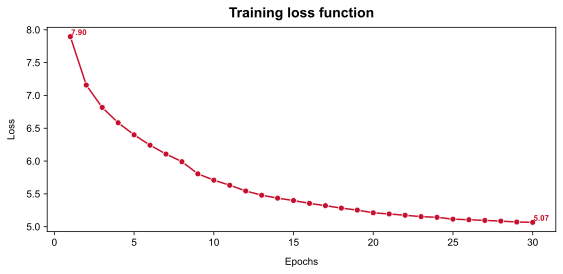

In [8]:
inputs = tf.keras.Input(shape=(1,), dtype=tf.string)
x = vectorizer(inputs)
x = tf.keras.layers.Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    trainable=False,
)(x)

# Convolutional layers with different kernel sizes
conv_3 = tf.keras.layers.Conv1D(128, 3, activation="relu")(x)
conv_4 = tf.keras.layers.Conv1D(128, 4, activation="relu")(x)
conv_5 = tf.keras.layers.Conv1D(128, 5, activation="relu")(x)

# Global max pooling for each convolutional output
pool_3 = tf.keras.layers.GlobalMaxPooling1D()(conv_3)
pool_4 = tf.keras.layers.GlobalMaxPooling1D()(conv_4)
pool_5 = tf.keras.layers.GlobalMaxPooling1D()(conv_5)

x = tf.keras.layers.Concatenate()([pool_3, pool_4, pool_5])
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[tf.keras.metrics.TopKCategoricalAccuracy(k=5, name="top5_accuracy")],
)

class MacroF1Callback(tf.keras.callbacks.Callback):
    def __init__(self, val_data):
        super().__init__()
        self.val_data = val_data

    def on_epoch_end(self, epoch, logs=None):
        y_true = []
        y_pred = []
        for x_batch, y_batch in self.val_data:
            probs = self.model.predict(x_batch, verbose=0)
            y_true.append(np.argmax(y_batch.numpy(), axis=1))
            y_pred.append(np.argmax(probs, axis=1))
        y_true = np.concatenate(y_true)
        y_pred = np.concatenate(y_pred)
        f1 = f1_score(y_true, y_pred, average="macro")
        if logs is not None:
            logs["val_macro_f1"] = f1
        print(f" - val_macro_f1: {f1:.4f}")

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
    MacroF1Callback(valid_ds),
]

history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=30,
    callbacks=callbacks,
)

# Vẽ biểu đồ loss
fig, ax = plt.subplots(figsize=(8, 4))
sns.set_theme(style="whitegrid")

loss_data = history.history["loss"]
epochs = list(range(1, len(loss_data) + 1))

epochs = range(1, len(history.history["loss"]) + 1)
sns.lineplot(x=epochs, y=history.history["loss"], label="Train Loss", marker="o", color="#C8102E", ax=ax, zorder=2)

ax.text(epochs[0] + 0.05, loss_data[0], f'{loss_data[0]:.2f}', size=8,
        verticalalignment='bottom', horizontalalignment='left', fontweight='bold', color='#C8102E')

ax.text(epochs[-1] + 0.05, loss_data[-1], f'{loss_data[-1]:.2f}', size=8,
        verticalalignment='bottom', horizontalalignment='left', fontweight='bold', color='#C8102E')

ax.set_title("Training loss function", fontsize=14, pad=10, fontweight='bold', loc='center')
ax.set_xlabel("Epochs", fontsize=10, labelpad=10)
ax.set_ylabel("Loss", fontsize=10, labelpad=10)
ax.legend().remove()

plt.tight_layout()
buf = BytesIO()
fig.savefig(buf, format='svg', bbox_inches='tight')
display(SVG(data=buf.getvalue().decode('utf-8')))
buf.close()
plt.close(fig)

## **6. Đánh giá và huấn luyện trên toàn bộ dữ liệu**

### 6.1 Đánh giá trên tập kiểm tra
Sau khi quá trình huấn luyện kết thúc, mô hình sẽ đánh giá độc lập trên tập kiểm thử (`test_ds`), để đánh giá mô hình, nhóm sử dụng hàm `predict` để xuất ra phân phối xác suất dự đoán cho toàn bộ tập test và tiến hành phân tích thông qua các độ đo như: `Top-5 Accuracy`, `Macro F1-Score` và báo cáo phân loại chi tiết.



In [9]:
model.evaluate(test_ds, verbose=0)

probs = model.predict(test_ds, verbose=0)
preds = np.argmax(probs, axis=1)

macro_f1 = f1_score(y_test, preds, average="macro", zero_division=0)
print("Macro F1:", macro_f1)

print("Classification report:")
print(classification_report(y_test, preds, zero_division=0))

# Top-k accuracy (k=5)
top_k = 5
topk_preds = np.argsort(probs, axis=1)[:, -top_k:]
y_test_np = y_test.to_numpy()
topk_hits = np.any(topk_preds == y_test_np.reshape(-1, 1), axis=1)
print(f"Top-{top_k} accuracy:", np.mean(topk_hits))

Macro F1: 0.06506048524179422
Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.00      0.00      0.00         1
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         7
          12       0.00      0.00      0.00         7
          13       0.08      0.14      0.10         7
          14       0.12      0.25      0.17         4
          16       0.00      0.00      0.00         8
          18       0.00      0.00      0.00         1
          23       0.00      0.00      0.00         8
          27       0.00      0.00      0.00         7
          28       0.00      0.00      0.00         2
          36       0.00      0.00      0.00         1
          37       0.00      0.00      0.00         1
          44       0.00      0.00      0.00         7
          48       0.00      0.00      0.00         8
          49       0.20     

### 6.2. Huấn luyện lại trên toàn bộ dữ liệu
Sau khi huấn luyện trên tập Train và kiểm thử trên tập Test, để mô hình đạt được hiệu quả và độ chính xác cao nhất trước khi cài đặt vào hệ thống gợi ý thì nhóm sẽ thực hiện quy trình huấn luyện lại (Retrain) để tích hợp toàn bộ dữ liệ hiện có.

- Các lớp vẫn sẽ được giữ nguyên kiến trúc giống quá trình huấn luyện ở bên trên, tuy nhiên dữ liệu dùng ở đây sẽ là dữ liệu tổng hợp từ cả ba tập Train - Valid - Test.

- Trong phần huấn luyện dữ liệu đối với tập Train, nhóm sử dụng biểu diễn nhãn theo `One-hot Encoding`. Tuy nhiên, khi đưa toàn bộ hàng chục ngàn dòng phân loại vào cùng một lúc, ma trận One-hot sẽ tiêu tốn một lượng RAM khổng lồ vô ích. Do đó, nhóm đã ra quyết định thay thế bằng kỹ thuật giữ nguyên nhãn số nguyên (Sparse labels) và chuyển qua sử dụng hàm/độ đo tương ứng là `SparseCategoricalCrossentropy` và `SparseTopKCategoricalAccuracy`.

- Do không còn tập Validation để theo dõi và kích hoạt cơ chế `EarlyStopping`, nhóm sẽ trích xuất vòng lặp tối ưu nhất (`best_epoch`) - epoch mang lại `val_loss` thấp nhất từng được lưu lại ở quá trình huấn luyện trước đó. Sẽ lấy chính con số này làm điều kiện dừng tuyệt đối cho mô hình khi huấn luyện trên toàn bộ dữ liệu.

Epoch 1/30
2146/2146 ━━━━━━━━━━━━━━━━━━━━ 75s 34ms/step - loss: 8.8212 - top5_accuracy: 0.0047
Epoch 2/30
2146/2146 ━━━━━━━━━━━━━━━━━━━━ 74s 35ms/step - loss: 8.2610 - top5_accuracy: 0.0091
Epoch 3/30
2146/2146 ━━━━━━━━━━━━━━━━━━━━ 74s 34ms/step - loss: 8.1285 - top5_accuracy: 0.0109
Epoch 4/30
2146/2146 ━━━━━━━━━━━━━━━━━━━━ 74s 34ms/step - loss: 7.8083 - top5_accuracy: 0.0186
Epoch 5/30
2146/2146 ━━━━━━━━━━━━━━━━━━━━ 74s 34ms/step - loss: 8.0018 - top5_accuracy: 0.0159
Epoch 6/30
2146/2146 ━━━━━━━━━━━━━━━━━━━━ 74s 34ms/step - loss: 7.2237 - top5_accuracy: 0.0225
Epoch 7/30
2146/2146 ━━━━━━━━━━━━━━━━━━━━ 73s 34ms/step - loss: 6.1907 - top5_accuracy: 0.0459
Epoch 8/30
2146/2146 ━━━━━━━━━━━━━━━━━━━━ 73s 34ms/step - loss: 5.6304 - top5_accuracy: 0.0854
Epoch 9/30
2146/2146 ━━━━━━━━━━━━━━━━━━━━ 74s 35ms/step - loss: 5.3317 - top5_accuracy: 0.1258
Epoch 10/30
2146/2146 ━━━━━━━━━━━━━━━━━━━━ 81s 38ms/step - loss: 5.1026 - top5_accuracy: 0.1633
Epoch 11/30
2146/2146 ━━━━━━━━━━━━━━━━━━━━ 73s 34

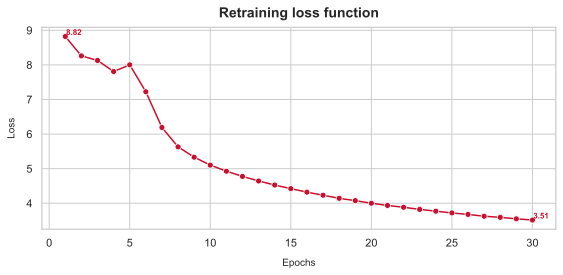

In [ ]:
# Re-train on full data for inference/production
df_full = df_main if "df_main" in globals() else df.copy()
if "label_id" not in df_full.columns:
    df_full["label_id"] = label_encoder.transform(df_full["Name"].astype(str))
X_full = df_full["comment_text"].values
y_full = df_full["label_id"].values.astype(np.int32)

vectorizer_full = tf.keras.layers.TextVectorization(
    standardize=custom_standardize,
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length,
 )
vectorizer_full.adapt(X_full)

vocab_full = vectorizer_full.get_vocabulary()
vocab_size_full = len(vocab_full)

if "ft_model" not in globals():
    ft_model = load_facebook_vectors(fasttext_path)

embedding_matrix_full = np.zeros((vocab_size_full, embedding_dim), dtype=np.float32)
for i, token in enumerate(vocab_full):
    if token in ("", "[UNK]"):
        continue
    try:
        embedding_matrix_full[i] = ft_model.get_vector(token)
    except KeyError:
        pass

# Use sparse labels to avoid large one-hot allocation
full_ds = tf.data.Dataset.from_tensor_slices((X_full, y_full))
full_ds = full_ds.shuffle(4096).batch(batch_size).prefetch(tf.data.AUTOTUNE)

best_epoch = int(np.argmin(history.history["val_loss"]) + 1) if "val_loss" in history.history else 10

inputs = tf.keras.Input(shape=(1,), dtype=tf.string)
x = vectorizer_full(inputs)
x = tf.keras.layers.Embedding(
    input_dim=vocab_size_full,
    output_dim=embedding_dim,
    weights=[embedding_matrix_full],
    trainable=False,
)(x)

conv_3 = tf.keras.layers.Conv1D(128, 3, activation="relu")(x)
conv_4 = tf.keras.layers.Conv1D(128, 4, activation="relu")(x)
conv_5 = tf.keras.layers.Conv1D(128, 5, activation="relu")(x)

pool_3 = tf.keras.layers.GlobalMaxPooling1D()(conv_3)
pool_4 = tf.keras.layers.GlobalMaxPooling1D()(conv_4)
pool_5 = tf.keras.layers.GlobalMaxPooling1D()(conv_5)

x = tf.keras.layers.Concatenate()([pool_3, pool_4, pool_5])
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model_full = tf.keras.Model(inputs, outputs)
model_full.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5_accuracy")],
)

start_retrain_time = time.time()

history_full = model_full.fit(full_ds, epochs=best_epoch)

retrain_time = time.time() - start_retrain_time
print(f"Training time: {retrain_time:.2f} giây")

# Vẽ biểu đồ loss
fig, ax = plt.subplots(figsize=(8, 4))
sns.set_theme(style="whitegrid")

loss_data = history_full.history["loss"]
epochs = list(range(1, len(loss_data) + 1))

sns.lineplot(x=epochs, y=loss_data, label="Train Loss", marker="o", color="#C8102E", ax=ax, zorder=2)

ax.text(epochs[0] + 0.05, loss_data[0], f'{loss_data[0]:.2f}', size=8,
        verticalalignment='bottom', horizontalalignment='left', fontweight='bold', color='#C8102E')

ax.text(epochs[-1] + 0.05, loss_data[-1], f'{loss_data[-1]:.2f}', size=8,
        verticalalignment='bottom', horizontalalignment='left', fontweight='bold', color='#C8102E')

ax.set_title("Retraining loss function", fontsize=14, pad=10, fontweight='bold', loc='center') 
ax.set_xlabel("Epochs", fontsize=10, labelpad=10)
ax.set_ylabel("Loss", fontsize=10, labelpad=10)
ax.legend().remove()

plt.tight_layout()
buf = BytesIO()
fig.savefig(buf, format='svg', bbox_inches='tight')
display(SVG(data=buf.getvalue().decode('utf-8')))
buf.close()
plt.close(fig)

# Use the full-data model for inference below
model = model_full
vectorizer = vectorizer_full

## **7. Lưu checkpoint**

Sau khi hoàn tất quá trình huấn luyện trên toàn bộ tập dữ liệu, việc lưu trữ lại là việc cần thiết, giúp hệ thống gợi ý có thể hoạt động độc lập ở các môi trường khác mà không cần phải thực hiện lại từ đầu các bước tiền xử lý hay huấn luyện mô hình từ đầu.

Thực hiện lưu trữ tại `./checkpoints/textcnn.pkl`, là 1 từ điển (`dictionary`) có tên checkpoint được xây dựng để đóng gói tập trung tất cả các tham số và cấu trúc dữ liệu quan trọng, bao gồm: trọng số mô hình, vector từ vựng, nhãn và các siêu tham số.

In [ ]:
checkpoint_dir = "../checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, "textcnn.pkl")

checkpoint = {
    "model_weights": model_full.get_weights(),
    "label_classes": label_encoder.classes_,
    "max_tokens": max_tokens,
    "sequence_length": sequence_length,
    "batch_size": batch_size,
    "embedding_dim": embedding_dim,
    "vocab_size": vocab_size_full,
    "vectorizer_vocab": vectorizer_full.get_vocabulary(),
}

with open(checkpoint_path, "wb") as f:
    pickle.dump(checkpoint, f, protocol=4)

print(f"Saved checkpoint at: {checkpoint_path}")

Đã lưu checkpoint vào: ../checkpoints\textcnn.pkl


## **8. Suy luận và hậu xử lý cho bài toán gợi ý**

Xây dựng một hệ thống hoàn chỉnh để tiếp nhận câu truy vấn tự nhiên của người dùng, suy luận và xử lý để đưa ra lộ trình các địa điểm phù hợp nhất.

- Thay vì phải phải chạy lại toàn bộ mã nguồn huấn luyện, hệ thống sẽ đọc đối tượng `checkpoint` từ tệp `.pkl` để khôi phục các thành phần của mô hình và trọng số tương ứng.

- Để hiển thị thông tin trực quan cho người dùng dựa trên kết quả của mô hình học sâu, nhóm xây dựng một bảng `lookup` chứa các siêu dữ liệu của các địa điểm trong bộ dữ liệu gốc.

- Ngoài việc sử dụng TextCNN để bắt ngữ nghĩa, nhóm kết hợp thêm các thông tin cụ thể từ câu mô tả đầu vào cả người dùng như giá, quận để có thể tăng thêm tính tương thích của kết quả gợi ý.

- Hàm `recommend(prompt)` đóng vai trò điều khiển từ câu mô tả của người dùng đến ra được danh sách các địa điểm gợi ý (bao gồm `3 attraction`, `2 dinning`, `1 hotel`):
    - Đưa câu truy vấn đi qua TextCNN, thu được một ma trận phân phối xác suất đo lường độ khớp của từng địa điểm ứng với câu truy vấn.

    - Để tránh việc hoàn toàn phụ thuộc vào kết quả của mô hình, nhóm thiết kế một công thức tính điểm dựa trên kết quả (mô hình) và độ phổ biến (thực tế): $\text{Final\_Score}=0.7 \times \text{Model\_Prob}+0.3 \times \text{Rank\_Score\_norm}$

    - Áp dụng các thông tin cụ thể trong câu mô tả của người dùng vào kết quả để giữ lại các địa điểm phù hợp nhất với câu mô tả đó.

    - Kết quả được sắp xếp theo `Final_Score` giảm dần và trả về một danh sách gợi ý hoàn chỉnh bao gồm 3 điểm tham quan (attraction), 2 quán ăn (dining), và 1 khách sạn (hotel).

In [12]:
# Load checkpoint
checkpoint_path = "../checkpoints/textcnn.pkl"
USE_CHECKPOINT = True

if USE_CHECKPOINT and os.path.exists(checkpoint_path):
    with open(checkpoint_path, "rb") as f:
        checkpoint = pickle.load(f)

    label_encoder = LabelEncoder()
    label_encoder.classes_ = checkpoint["label_classes"]

    max_tokens = int(checkpoint["max_tokens"])
    sequence_length = int(checkpoint["sequence_length"])
    embedding_dim = int(checkpoint.get("embedding_dim", 300))
    vocab = checkpoint["vectorizer_vocab"]

    vectorizer = tf.keras.layers.TextVectorization(
        standardize=custom_standardize,
        max_tokens=max_tokens,
        output_mode="int",
        output_sequence_length=sequence_length,
    )
    vectorizer.set_vocabulary(vocab)

    num_classes = len(label_encoder.classes_)
    vocab_size = len(vocab)

    inputs = tf.keras.Input(shape=(1,), dtype=tf.string)
    x = vectorizer(inputs)
    x = tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
    )(x)
    conv_3 = tf.keras.layers.Conv1D(128, 3, activation="relu")(x)
    conv_4 = tf.keras.layers.Conv1D(128, 4, activation="relu")(x)
    conv_5 = tf.keras.layers.Conv1D(128, 5, activation="relu")(x)
    pool_3 = tf.keras.layers.GlobalMaxPooling1D()(conv_3)
    pool_4 = tf.keras.layers.GlobalMaxPooling1D()(conv_4)
    pool_5 = tf.keras.layers.GlobalMaxPooling1D()(conv_5)
    x = tf.keras.layers.Concatenate()([pool_3, pool_4, pool_5])
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer="adam",
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=[tf.keras.metrics.TopKCategoricalAccuracy(k=5, name="top5_accuracy")],
)

    _ = model(np.array(["dummy"], dtype=object))
    model.set_weights(checkpoint["model_weights"])
    print("Loaded checkpoint successfully")
else:
    print("Error: Checkpoint not found")

# Inference
lookup_cols = ["Name", "Address", "Score", "Nums_comments", "Price_min", "Price_max", "Category", "Start", "End", "Comment_scores",
    "rank_score",]

df_inference = df.copy() if "df" in globals() else None

if "rank_score" not in df_inference.columns:
    df_inference["comment_score_mean"] = df_inference["Comment_scores"].apply(parse_comment_scores)
    df_inference["rank_score"] = df_inference["Score"].copy()
    df_inference.loc[df_inference["rank_score"].isna(), "rank_score"] = df_inference["comment_score_mean"]
    df_inference["rank_score"] = df_inference["rank_score"].fillna(df_inference["rank_score"].mean())

df_inference["Name"] = df_inference["Name"].astype(str)
lookup = df_inference.drop_duplicates(subset=["Name"])[lookup_cols].copy()
lookup = lookup.set_index("Name", drop=False)
lookup["label_id"] = label_encoder.transform(lookup.index)  # for fast join

score_min = lookup["rank_score"].min()
score_max = lookup["rank_score"].max()
if score_max > score_min:
    lookup["rank_score_norm"] = (lookup["rank_score"] - score_min) / (score_max - score_min)
else:
    lookup["rank_score_norm"] = 0.0

def remove_accents(input_str):
    if not input_str:
        return ""
    s1 = unicodedata.normalize('NFD', input_str)
    s2 = re.sub(r'[\u0300-\u036f]', '', s1)
    s2 = s2.replace('đ', 'd').replace('Đ', 'D')

    return s2

def parse_prompt_filters(prompt):
    prompt = remove_accents(prompt or "").lower()
    filters = {"district": None, "price_min": None, "price_max": None}

    for pattern in [r"quan\s*(\d+)", r"q\s*(\d+)", r"district\s*(\d+)"]:
        m = re.search(pattern, prompt)
        if m:
            filters["district"] = m.group(1)
            break

    if not filters["district"]:
        m = re.search(r"(?:quan|huyen|thanh pho|tp)\s+([a-z0-9\s]+)", prompt)
        if m:
            name = m.group(1).strip()
            name = re.split(r"[,.;]|\bco\b|\bchi\b|\bphi\b|\bduoi\b|\btren\b|\btu\b|\bden\b", name)[0].strip()
            if name:
                filters["district"] = name

    numbers = [int(n) for n in re.findall(r"\d+", prompt)]

    if filters["district"] and str(filters["district"]).isdigit():
        district_num = int(filters["district"])
        if district_num in numbers:
            numbers.remove(district_num)

    if "tu" in prompt and "den" in prompt and len(numbers) >= 2:
        filters["price_min"], filters["price_max"] = numbers[0], numbers[1]
    elif "duoi" in prompt and numbers:
        filters["price_max"] = max(numbers)
    elif "tren" in prompt and numbers:
        filters["price_min"] = max(numbers)

    return filters

def apply_filters(df_in, filters):
    df_out = df_in.copy()
    if filters.get("district"):
        district = str(filters["district"]).strip()
        if district.isdigit():
            pattern = rf"(?:quan|quận|district|q)\s*{re.escape(district)}(?!\d)"
            district_mask = df_out["Address"].str.contains(pattern, case=False, na=False, regex=True)
        else:
            district_norm = remove_accents(district).lower()
            address_norm = df_out["Address"].fillna("").apply(remove_accents).str.lower()
            pattern = rf"(?:quan|huyen|thanh pho|tp)\s*{re.escape(district_norm)}"
            district_mask = address_norm.str.contains(pattern, regex=True) | address_norm.str.contains(
                rf"\b{re.escape(district_norm)}\b", regex=True
            )
        df_out = df_out[district_mask]

    if filters.get("price_min") is not None:
        df_out = df_out[df_out["Price_max"].fillna(0) >= filters["price_min"]]
    if filters.get("price_max") is not None:
        df_out = df_out[df_out["Price_min"].fillna(0) <= filters["price_max"]]

    return df_out

def recommend(prompt):
    top_config = {"attraction": 3, "dining": 2, "hotel": 1}

    prompt_tensor = np.array([prompt], dtype=object)
    pred_probs = model.predict(prompt_tensor, verbose=0)[0]
    prob_map = dict(zip(label_encoder.classes_, pred_probs))            # Danh sach diem cua CNN (dia diem: diem)

    df_rank_all = lookup.copy()
    df_rank_all["model_prob"] = df_rank_all["Name"].map(prob_map).fillna(0.0)   
    df_rank_all["final_score"] = df_rank_all["model_prob"] * 0.7 + df_rank_all["rank_score_norm"] * 0.3

    filters = parse_prompt_filters(prompt)

    df_rank_filtered = apply_filters(df_rank_all, filters)
    if df_rank_filtered.empty:
        df_rank_filtered = df_rank_all

    results = {}
    for category, top_k in top_config.items():
        sub = df_rank_filtered[df_rank_filtered["Category"] == category]
        sub = sub.sort_values("final_score", ascending=False).head(top_k)

        if len(sub) < top_k:
            fallback = df_rank_all[df_rank_all["Category"] == category]
            if not sub.empty:
                fallback = fallback[~fallback["Name"].isin(sub["Name"])]
            sub = pd.concat([sub, fallback]).sort_values("final_score", ascending=False).head(top_k)
        results[category] = sub

    for category, df in results.items():
        results[category] = df[["Name", "Address", "Price_min", "Price_max", "Category"]]

    return results

Loaded checkpoint successfully


In [ ]:
# Testing
sample_prompts = [
    "Tôi muốn đi tham quan",
] * 100

_ = recommend("warm up")

start_infer = time.time()
for p in sample_prompts:
    _ = recommend(p)
end_infer = time.time()

avg_infer_time = (end_infer - start_infer) / len(sample_prompts)

print(f"Inference time: {avg_infer_time:.2f} giây") 

Thời gian suy luận: 0.06 giây


## **9. Đánh giá độ phức tạp và chi phí của mô hình**

In [ ]:
checkpoint_path = "../checkpoints/textcnn.pkl"
file_size_mb = os.path.getsize(checkpoint_path) / (1024 * 1024) if os.path.exists(checkpoint_path) else 0

total_params = model.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
non_trainable_params = total_params - trainable_params

print(f"Storage cost: {file_size_mb:.2f} MB")
print(f"Total parameters: {total_params:,}")

model.summary()

Chi phí lưu trữ: 32.29 MB
Tổng lượng tham số: 8,099,939


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization… │ (None, 100)       │          0 │ input_layer_2[0]… │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 100, 300)  │  6,000,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 98, 128)   │    115,328 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 97, 128)   │    153,728 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 96, 128)   │    192,128 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_6[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_7[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_8[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 384)       │      1,536 │ concatenate_2[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 384)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     98,560 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 5987)      │  1,538,659 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,099,939 (30.90 MB)

 Trainable params: 8,099,171 (30.90 MB)

 Non-trainable params: 768 (3.00 KB)

## **10. Tổng kết về mô hình**

### 10.1 Điểm mạnh 

### 10.2 Điểm yếu

### 10.3 Quan sát thực nghiệm